# SRA Learning & Routing Demo (Copy Task)

このノートブックでは、SRAモデルに簡単なタスク（Copyタスク：入力された数列をそのまま出力する）を学習させます。
学習の前後で**「ルーティング（各入力トークンがどのシナプスに割り当てられるか）」がどう変化するか**を可視化し、SRAがタスクに特化して専門家（シナプス）を使い分ける様子を観察します。

## 1. 環境セットアップ
Google Colabの場合は以下のセルを実行してください。

In [1]:
import sys
if 'google.colab' in sys.modules:
    !git clone https://github.com/JunSuzukiJapan/SynapticRouter.git
    %cd SynapticRouter
    !pip install torch matplotlib seaborn

sys.path.append('.')
sys.path.append('./src')
if 'google.colab' not in sys.modules:
    sys.path.append('..')
    sys.path.append('../src')


## 2. ライブラリのインポートとモデルの準備

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F

from src.sra_gpu_models import MoESRAModel
class MoESRAConfig:
    def __init__(self, **kwargs):
        for k, v in kwargs.items():
            setattr(self, k, v)
from src.sra_experiment import make_batch, make_optimizer, load_balance_loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 学習が早く進むように、少し小さめのモデルを設定
config = MoESRAConfig(
    vocab_size=20,
    d_model=64,
    n_layers=2,
    n_heads=2,
    num_synapses=4,  # 4つの専門家（シナプス）
    k=2,
    max_seq_len=32
)
model = MoESRAModel(config.vocab_size, config.d_model, config.n_layers, config.num_synapses, config.k, syn_hidden=128).to(device)
optimizer = make_optimizer(model, lr=0.005)

Using device: cpu


## 3. 可視化関数の定義
ルーティングの重みをヒートマップで表示するための関数を準備します。

=== 学習前 (Before Training) ===


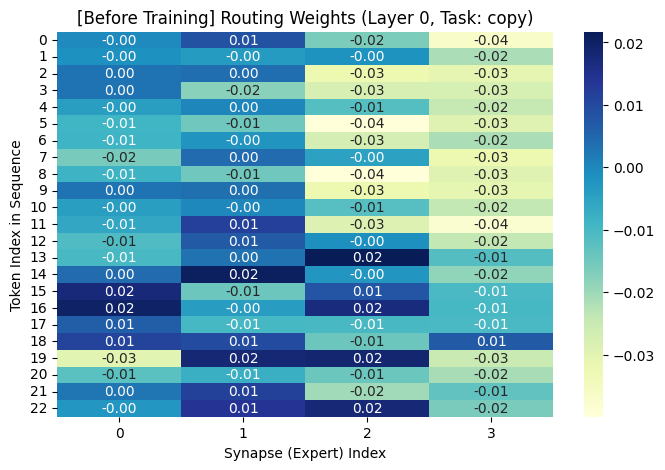

In [3]:
def visualize_routing(model, task="copy", title_prefix=""):
    model.eval()
    # 評価用のバッチを作成 (シーケンス長10)
    x, y = make_batch(task, batch_size=1, min_len=10, max_len=10, device=device)
    
    with torch.no_grad():
        y_in = torch.cat([torch.full((y.size(0), 1), 1, dtype=torch.long, device=device), y[:, :-1]], dim=1)
        outputs, routing_weights, _ = model(x, y_in)
        
    # 最初のレイヤーのルーティング重みを取得
    layer_idx = 0
    weights = routing_weights[layer_idx][0].cpu().numpy()
    
    plt.figure(figsize=(8, 5))
    sns.heatmap(weights, cmap="YlGnBu", annot=True, fmt=".2f")
    plt.title(f"{title_prefix} Routing Weights (Layer {layer_idx}, Task: {task})")
    plt.xlabel("Synapse (Expert) Index")
    plt.ylabel("Token Index in Sequence")
    plt.show()

# 学習前の状態を可視化
print("=== 学習前 (Before Training) ===")
visualize_routing(model, title_prefix="[Before Training]")

## 4. 学習の実行 (Copy Task)
数エポックだけ「Copyタスク（入力をそのまま出力する）」を学習させます。

In [4]:
print("Training started...")
model.train()

epochs = 300
batch_size = 32

for epoch in range(epochs):
    x, y = make_batch("copy", batch_size, 5, 10, device)
    
    optimizer.zero_grad()
    y_in = torch.cat([torch.full((y.size(0), 1), 1, dtype=torch.long, device=device), y[:, :-1]], dim=1)
    outputs, routing_weights, _ = model(x, y_in)
    
    # CrossEntropyLoss (出力の形状を合わせる)
    # outputs: [batch, seq, vocab], y: [batch, seq]
    loss = F.cross_entropy(outputs.reshape(-1, config.vocab_size), y.reshape(-1))
    
    # ルーターの負荷分散ロスを追加 (特定の専門家ばかり使われないようにする)
    lb_loss = load_balance_loss(routing_weights) * 0.1
    total_loss = loss + lb_loss
    
    total_loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f} | LB Loss: {lb_loss.item():.4f}")

print("Training finished!")

Training started...


Epoch 50/300 | Loss: 1.5175 | LB Loss: 3.6000


Epoch 100/300 | Loss: 0.0543 | LB Loss: 3.6000


Epoch 150/300 | Loss: 0.0017 | LB Loss: 3.6000


Epoch 200/300 | Loss: 0.0002 | LB Loss: 3.6000


Epoch 250/300 | Loss: 0.0001 | LB Loss: 3.6000


Epoch 300/300 | Loss: 0.0001 | LB Loss: 3.6000
Training finished!


## 5. 学習後のルーティングと推論の確認
学習前後でルーティング（ヒートマップの偏り）がどう変化したかを確認します。
学習が進むと、ルーターが特定の専門家（シナプス）を意図的に選ぶようになり、重みが偏る（特化する）様子が観察できるはずです。

=== 学習後 (After Training) ===


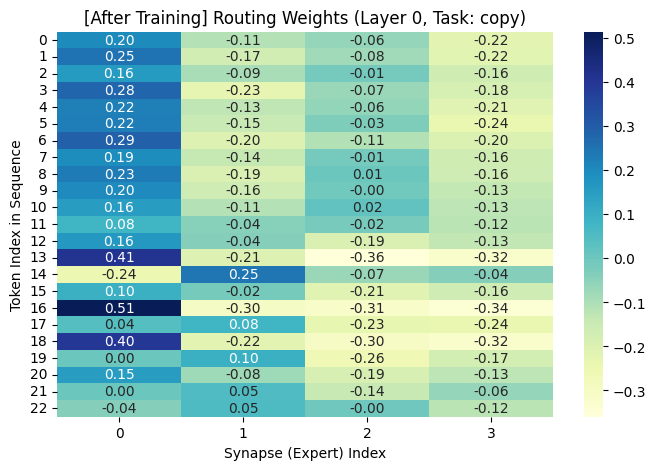


--- 推論結果 ---
Input (Target) : [8, 4, 12, 9, 13, 12, 8, 4, 2]
Prediction     : [8, 4, 12, 9, 13, 12, 8, 4, 2]

=> 成功！モデルはコピーを学習しました。


In [5]:
print("=== 学習後 (After Training) ===")
visualize_routing(model, title_prefix="[After Training]")

# 実際にタスクが解けているか推論してみる
model.eval()
x, y = make_batch("copy", batch_size=1, min_len=8, max_len=8, device=device)
with torch.no_grad():
    outputs, _, _ = model(x, torch.zeros_like(y))
    preds = outputs.argmax(dim=-1)
    
print("\n--- 推論結果 ---")
print(f"Input (Target) : {y[0].tolist()}")
print(f"Prediction     : {preds[0].tolist()}")
if y[0].tolist() == preds[0].tolist():
    print("\n=> 成功！モデルはコピーを学習しました。")
else:
    print("\n=> 失敗... もう少し学習ステップ数(epochs)が必要かもしれません。")